In [1]:
from typing import Optional
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.nn import ReLU

from pfhedge.instruments import BrownianStock
from pfhedge.instruments import EuropeanOption
from pfhedge.instruments import FixedStock
from pfhedge.nn import BlackScholes
from pfhedge.nn import EntropicRiskMeasure
from pfhedge.nn import ExpectedShortfall
from pfhedge.nn import Hedger
from pfhedge.nn import MultiLayerPerceptron
from pfhedge.nn import BSEuropeanOption

### Utility

In [2]:
def generate_log_normal_brownian(
    sigma: float, mu: float, dt: float, n_steps: int, seed: Optional[int] = None
) -> Tuple[torch.Tensor, torch.Tensor]:

    """Generate a log-normal Brownian motion time series.
    Args:
        sigma (float): Volatility parameter.
        dt (float): Time step size.
        n_steps (int): Number of time steps.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        Tuple[torch.Tensor, torch.Tensor]: Tuple containing the log series and the
            exponential series.
    """
    if seed is not None:
        torch.manual_seed(seed)
    # Generate Brownian increments
    increments = torch.randn(n_steps - 1) * np.sqrt(sigma**2 * dt) + mu * dt
    # Convert to log-normal Brownian motion
    log_series = torch.cat([torch.zeros(1), torch.cumsum(increments, dim=0)])
    series = torch.exp(log_series)
    return series


def get_derivative(
    sigma: float, mu: float, dt: float, strike: float, maturity: float, cost: float = 0.0
) -> EuropeanOption:
    stock = BrownianStock(cost=cost, sigma=sigma, mu=mu, dt=dt)
    derivative = EuropeanOption(stock, strike=strike, maturity=maturity)
    return derivative


def loss_hedger(loss, derivative, features, n_epochs, n_paths) -> Hedger:
    # Create MLP hedger
    model = MultiLayerPerceptron(
        n_layers=4, n_units=[64, 32, 32, 16], activation=ReLU()
    )
    hedger = Hedger(model, features, criterion=loss)
    # Fit the hedger
    hedger.fit(derivative, n_epochs=n_epochs, n_paths=n_paths)
    return hedger


def blackscholes_hedger(derivative) -> Hedger:
    # Create instruments
    model = BlackScholes(derivative)
    hedger_bs = Hedger(model, model.inputs())
    return hedger_bs

### Instruments

In [3]:
torch.manual_seed(1234)

# Set up the underlyer
dt = 1 / 250
vol = 0.4
mu = 0.0
spot = 1.0
cost = 0.001

# Set up the derivative
strike = 1.0
term = 30
maturity = term * dt
features = ["log_moneyness", "expiry_time", "volatility", "prev_hedge"]

# Set trainging parameters
n_epochs = 200
n_paths = 10000

series = generate_log_normal_brownian(sigma=vol, mu=mu, dt=dt, n_steps=term + 1)
fixed_stock = FixedStock(spots=list(series), cost=cost, dt=dt)
sigma = fixed_stock.volatility  # use realized volatility in simulation
print(f"Realized Volatility: {sigma:.6f}")

Realized Volatility: 0.333351


### Hedgers

In [4]:
# Set up the hedgers
loss_functions = {
    "Entropic Risk Measure (a=1)": EntropicRiskMeasure(a=1),
    "Entropic Risk Measure (a=0.1)": EntropicRiskMeasure(a=0.1),
    "Expected Shortfall (95%)": ExpectedShortfall(p=0.05),
    "Expected Shortfall (50%)": ExpectedShortfall(p=0.5),
}
hedgers = {}
derivative = get_derivative(sigma, mu=mu, dt=dt, cost=cost, strike=strike, maturity=maturity)
hedger = blackscholes_hedger(derivative)
hedgers["Black-Scholes"] = (hedger, derivative)
for name, loss in loss_functions.items():
    derivative = get_derivative(sigma, mu=mu, dt=dt, cost=cost, strike=strike, maturity=maturity)
    hedger = loss_hedger(loss, derivative, features, n_epochs, n_paths)
    hedgers[name] = (hedger, derivative)

Loss=0.0556: 100%|██████████| 200/200 [00:33<00:00,  6.03it/s]


### PnL Distribution

In [5]:
# PnL statistics
pnls = {}
for name, (hedger, derivative) in hedgers.items():
    derivative.simulate(n_paths=10000)
    pnls[name] = hedger.compute_pl(derivative)
print("PnL Statistics:")
for name, pnl in pnls.items():
    print(f"{name}: {pnl.mean():.6f} ({pnl.std():.6f})")

PnL Statistics:
Black-Scholes: -0.048279 (0.007350)
Entropic Risk Measure (a=1): -0.046320 (0.035106)
Entropic Risk Measure (a=0.1): -0.045591 (0.070007)
Expected Shortfall (95%): -0.047700 (0.012067)
Expected Shortfall (50%): -0.047745 (0.010158)


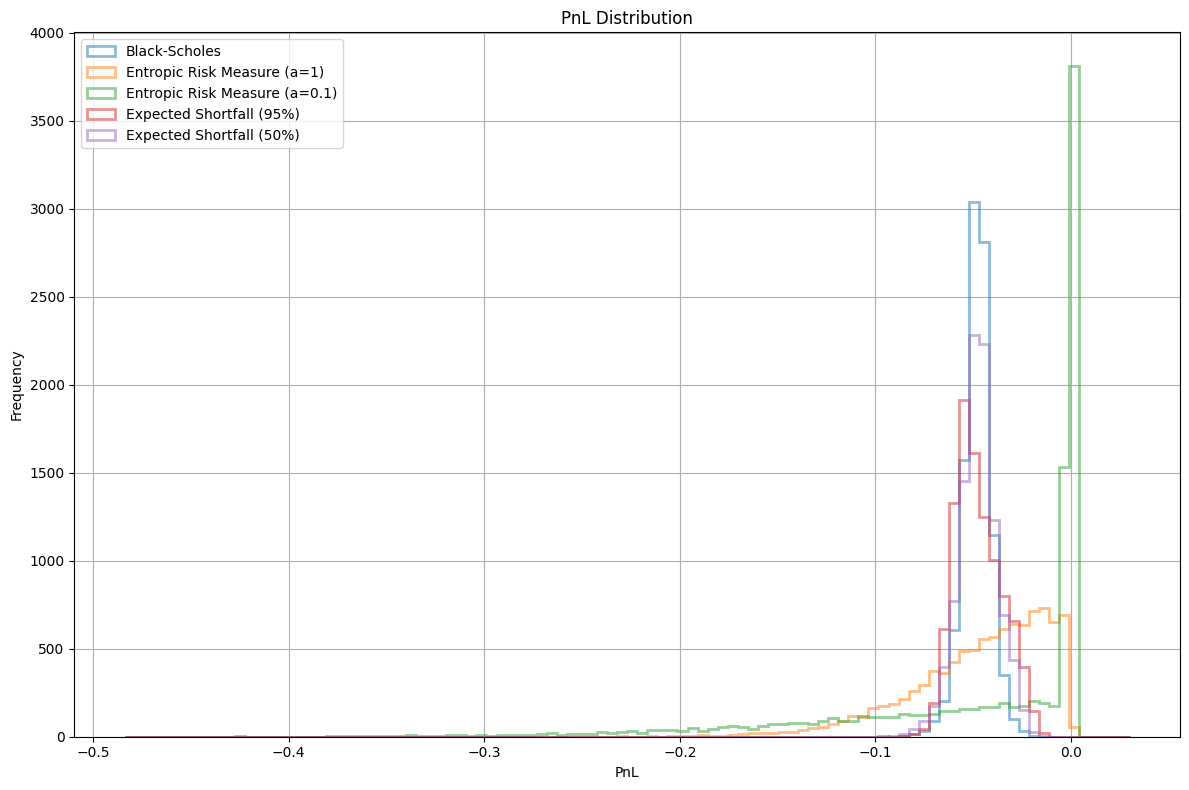

In [6]:
selected_pnls = {
    k: v for k, v in pnls.items()
    # if k in ["Entropic Risk Measure (a=1)", "Entropic Risk Measure (a=0.1)", "Expected Shortfall (95%)", "Expected Shortfall (50%)"]
}
# Calculate global min and max for uniform binning
all_pnls = torch.cat([pnl for pnl in selected_pnls.values()]).detach().numpy()
bin_edges = np.linspace(all_pnls.min(), all_pnls.max(), 101)
# Plot PnL distributions
plt.figure(figsize=(12, 8))
for name, pnl in selected_pnls.items():
    plt.hist(pnl.detach().numpy(), bins=bin_edges, label=name, histtype='step', linewidth=2, alpha=0.5)
plt.title('PnL Distribution')
plt.xlabel('PnL')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Backtest (Mock)

In [7]:
# Backtest on the fixed stock
fixed_derivative = EuropeanOption(fixed_stock, strike=strike, maturity=maturity)
fixed_derivative.simulate(n_paths=1)
for name, (hedger, _) in hedgers.items():
    pnl = hedger.compute_pl(fixed_derivative, [fixed_stock])
    print(f"{name}: {pnl.item()}")

Black-Scholes: -0.046766214072704315
Entropic Risk Measure (a=1): -0.05112706869840622
Entropic Risk Measure (a=0.1): -0.0007048580446280539
Expected Shortfall (95%): -0.053512923419475555
Expected Shortfall (50%): -0.046817053109407425


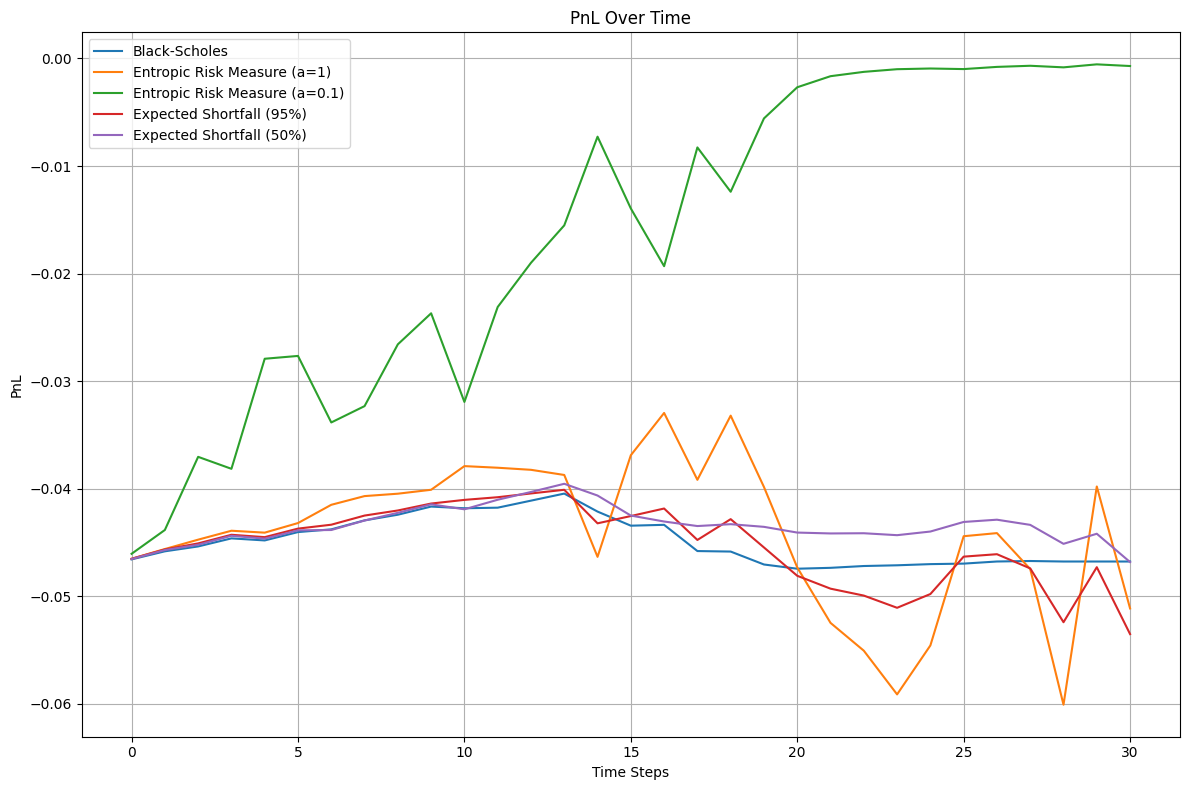

In [8]:
# daily PnL
bs_priceable = BSEuropeanOption.from_derivative(fixed_derivative)
daily_pnls = {}
for name, (hedger, _) in hedgers.items():
    daily_pnls[name] = hedger.compute_cum_pl(fixed_derivative, priceable=bs_priceable)

# Plot daily PnL
daily_pnls = {name: pnl[0].detach().numpy() for name, pnl in daily_pnls.items()}
plt.figure(figsize=(12, 8))
for name, pnl in daily_pnls.items():
    plt.plot(pnl, label=name)
plt.title("PnL Over Time")
plt.xlabel("Time Steps")
plt.ylabel("PnL")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()